# 全局联邦学习算法对比分析 (Global FL Analysis)

本 Notebook 用于对比分析传统的全局联邦学习算法（如 FedAvg, FedProx, Scaffold 等）在相同实验配置下的性能表现。

In [8]:
import os
import sys
import torch
import matplotlib.pyplot as plt

# 添加项目根目录到路径
sys.path.append(os.path.abspath(os.path.join(os.getcwd(), "..")))
from plot.utils import load_plot, load_plot_all_runs, ResultLoader

In [9]:
# --- 实验组定义 ---
experiments = {
    # 基础算法
    "FedAvg": ("fedavg", {}),
    "FedProx": ("fedprox", {"mu": 0.01}),
    "Scaffold": ("scaffold", {"global_lr": 1.0}),
    "FedDyn": ("feddyn", {"alpha_coef": 0.1}),

    # 进阶/特征对齐算法
    "FedProc": ("fedproc", {}),
    "FedFM": ("fedfm", {"mu": 1.0}),
    "MOON": ("moon", {"mu": 0.01, "tau": 0.5}),
    "FedLSA": ("fedlsa", {"lambda_com": 0.1, "alpha_sep": 0.1, "server_epochs": 10, "server_lr": 0.01, "tau": 0.1})
}

# --- 通用参数 ---
common_args = {
    "dataset": "cifar10",
    "partition": "dirichlet",
    "alpha": 0.1,
    "num_clients": 10,
    "rounds": 200,
    "epochs": 10,
    "lr": 0.01,
    "batch_size": 64
}

loader = ResultLoader(base_dir="../results_ray")

  [提示] 结果文件不存在: ../results_ray/fedfm/cifar10_dirichlet_10_0.1/10_64_0.01_1.0_X.pt
Figure saved to figures/test_accuracy_on_cifar10_dirichlet.png

Summary of ACC:
-----------------------------------------------------------------
Algorithm            |         Max Acc |     Last 10 Avg
-----------------------------------------------------------------
FedAvg               |         65.4500 |         65.0142
FedProx              |         65.4750 |         65.2375
Scaffold             |         66.0917 |         65.6508
FedDyn               |         65.6833 |         64.3300
FedProc              |         54.2667 |         52.1775
MOON                 |         65.3667 |         64.9192
FedLSA               |         41.0167 |         40.8208
-----------------------------------------------------------------


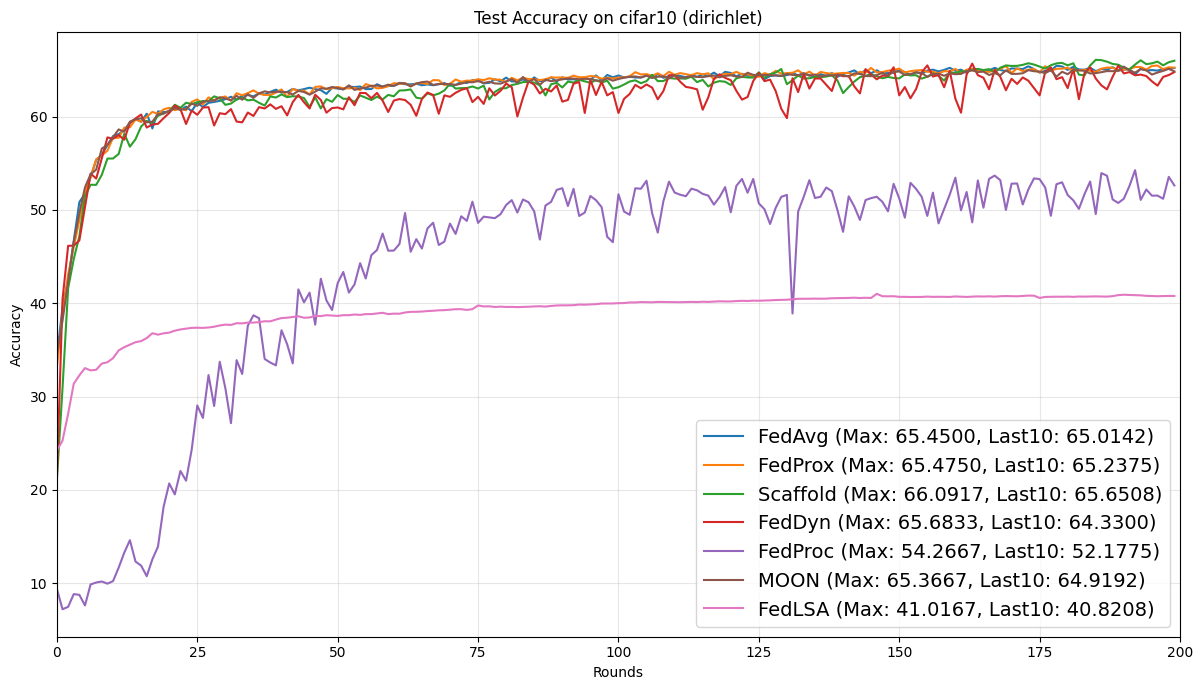

In [10]:
# 1. 加载并绘制曲线 (Run 0)
load_plot(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)

In [11]:
# 2. 统计所有 Run 的平均性能
load_plot_all_runs(
    selected_group=list(experiments.keys()),
    experiments=experiments,
    common_args=common_args,
    loader=loader,
    x_lim=200
)


Summary of ALL RUNS (Mean ± Std):
---------------------------------------------------------------------------
Algorithm                 |              Max Acc |          Last 10 Avg
---------------------------------------------------------------------------
FedAvg                    |  65.4483 ± 0.0744  |  65.1173 ± 0.0903  (5 runs)
FedProx                   |  65.4867 ± 0.0983  |  65.2807 ± 0.0915  (5 runs)


Scaffold                  |  66.0683 ± 0.0718  |  65.2873 ± 0.4304  (5 runs)
FedDyn                    |  65.6333 ± 0.1273  |  63.9805 ± 0.3255  (5 runs)
FedProc                   |  55.0483 ± 0.4688  |  51.5438 ± 1.1636  (5 runs)
  [提示] 结果文件不存在: ../results_ray/fedfm/cifar10_dirichlet_10_0.1/10_64_0.01_1.0_X.pt
MOON                      |  65.2917 ± 0.1613  |  64.8877 ± 0.1070  (5 runs)
FedLSA                    |  40.9100 ± 0.2092  |  40.8107 ± 0.2263  (5 runs)
